# Análise de nanotoxicidade em nanopartículas por algoritmo *k*-NN

**Disciplina:** Aprendizado de máquina

**Docente:** Daniel Roberto Cassar 

**Discente e autor:** Leonardo Ramos Gomes da Silva 

## Introdução

As nanopartículas (NPs) estão em um crescente uso em diversas aplicações, dentre elas, a medicina. Suas aplicações vão desde utilização com ação antibacteriana à *drug delivery*. Neste contexto, é muito útil que se crie um modelo capaz de prever a toxicidade dessas NPs para maior eficiência. Este caderno, pois, demonstra a implementação do algoritmo de *k*-**vizinhos mais próximos** (*k*-NN) com o objetivo de prever a toxicidade, baseado em diversos atributos, tais como: o material de que são feitas, o tamanho do núcleo, o tamanho hidrodinâmico, a carga de superfície, a área de superfície, a energia de valência, a energy-related feature, o tempo de exposição e a dosagem. O banco de dados utilizado para treinar o modelo é o *"Nanoparticle Toxicity Dataset"*, disponibilizado pela plataforma Kaggle. A finalidade do caderno não é prover o melhor modelo para fazer a previsão, mas realizar um estudo em torno desse modelo e a sua aplicação com o módulo `scikit`.

## Tratamento de dados

Importando todas as bibliotecas utilizadas e respectivas funções, utilizadas a diante.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MaxAbsScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from itertools import product

O banco de dados será então introduzido e tratado. O método `df.dropna`, do módulo `pandas`, garante que não tenham exemplos com dados indisponíveis para a análise. Interessante notar que não há dados faltantes.

In [2]:
df = pd.read_csv("nanotox_dataset.csv")

ATRIBUTOS = ["NPs", "coresize", "hydrosize", "surfcharge", "surfarea", "Ec", "e",
       "Expotime", "dosage"]
TARGET = ["class"]

x = df.reindex(ATRIBUTOS, axis=1)
y = df.reindex(TARGET, axis=1)

df = df.reindex(ATRIBUTOS + TARGET, axis=1)
print(f"O modelo tinha {df.shape[0]} amostras")
df = df.dropna()
print(f"Após remover amostras com valores ausentes, o modelo tem {df.shape[0]} amostras")

O modelo tinha 881 amostras
Após remover amostras com valores ausentes, o modelo tem 881 amostras


Vejamos os atributos.

In [3]:
x.head(10)

,NPs,coresize,hydrosize,surfcharge,surfarea,Ec,e,Expotime,dosage
0,Al2O3,39.7,267.0,36.3,64.7,-1.51,1.61,24,0.001
1,Al2O3,39.7,267.0,36.3,64.7,-1.51,1.61,24,0.010
2,Al2O3,39.7,267.0,36.3,64.7,-1.51,1.61,24,0.100
3,Al2O3,39.7,267.0,36.3,64.7,-1.51,1.61,24,1.000
4,Al2O3,39.7,267.0,36.3,64.7,-1.51,1.61,24,5.000
5,Al2O3,39.7,267.0,36.3,64.7,-1.51,1.61,24,10.000
6,Al2O3,39.7,267.0,36.3,64.7,-1.51,1.61,24,20.000
7,Al2O3,39.7,267.0,36.3,64.7,-1.51,1.61,24,50.000
8,Al2O3,39.7,267.0,36.3,64.7,-1.51,1.61,24,100.000
9,Al2O3,39.7,267.0,36.3,64.7,-1.51,1.61,12,0.001


Vejamos o target.

In [4]:
y.head(10)

,class
0,nonToxic
1,nonToxic
2,nonToxic
3,nonToxic
4,nonToxic
5,nonToxic
6,nonToxic
7,nonToxic
8,nonToxic
9,nonToxic


Antes de seguir em frente, o atributo `NPs` será convertido em número, utilizando a técnica do One Hot Encoder [1]. A técnica consiste na transformação de dados categóricos em binário, criando uma coluna binária para cada categoria.

In [5]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.set_output(transform="pandas")

encoded_df = encoder.fit_transform(df[['NPs']])

df = pd.concat([df, encoded_df], axis=1).drop(columns=['NPs'])

df

,coresize,hydrosize,surfcharge,surfarea,Ec,e,Expotime,dosage,class,NPs_Al2O3,NPs_CuO,NPs_Fe2O3,NPs_TiO2,NPs_ZnO
0,39.7,267.0,36.3,64.7,-1.51,1.61,24,0.001,nonToxic,1.0,0.0,0.0,0.0,0.0
1,39.7,267.0,36.3,64.7,-1.51,1.61,24,0.010,nonToxic,1.0,0.0,0.0,0.0,0.0
2,39.7,267.0,36.3,64.7,-1.51,1.61,24,0.100,nonToxic,1.0,0.0,0.0,0.0,0.0
3,39.7,267.0,36.3,64.7,-1.51,1.61,24,1.000,nonToxic,1.0,0.0,0.0,0.0,0.0
4,39.7,267.0,36.3,64.7,-1.51,1.61,24,5.000,nonToxic,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
876,45.3,310.0,32.7,21.3,-3.89,1.65,24,20.000,Toxic,0.0,0.0,0.0,0.0,1.0
877,32.0,1093.0,21.6,37.0,-3.89,1.65,24,25.000,Toxic,0.0,0.0,0.0,0.0,1.0
878,46.3,239.0,42.8,24.1,-5.17,1.90,12,100.000,Toxic,0.0,0.0,0.0,0.0,1.0
879,35.6,295.5,-41.6,27.9,-3.89,1.65,24,10.000,Toxic,0.0,0.0,0.0,0.0,1.0


Utilizando o método `describe()` para analisar a diferença média geral entre nanopartículas não tóxicas e tóxicas para uma rápida análise. A primeira será das partículas não tóxicas.

In [6]:
#Describe em partículas não tóxicas
logica = df["class"] == "nonToxic"

df.loc[logica].describe()

,coresize,hydrosize,surfcharge,surfarea,Ec,e,Expotime,dosage,NPs_Al2O3,NPs_CuO,NPs_Fe2O3,NPs_TiO2,NPs_ZnO
count,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000
mean,47.966667,522.805185,-4.405432,61.107654,-3.997210,1.610321,21.977778,31.803132,0.044444,0.027160,0.044444,0.479012,0.404938
std,31.236046,411.580450,22.644049,60.172709,0.611865,0.086306,18.077172,46.244915,0.206335,0.162752,0.206335,0.500177,0.491487
min,7.500000,74.000000,-41.600000,7.000000,-5.170000,1.540000,3.000000,0.000010,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25.000000,267.000000,-11.700000,20.000000,-4.160000,1.540000,6.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,35.600000,310.000000,-10.700000,40.000000,-4.160000,1.610000,24.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,60.000000,687.000000,-2.400000,66.000000,-3.890000,1.650000,24.000000,40.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,125.000000,1843.000000,42.800000,210.000000,-1.510000,1.900000,72.000000,300.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Abaixo está o método `describe()` apenas em partículas tóxicas.

In [7]:
#Describe em partículas tóxicas

df.loc[~logica].describe()

,coresize,hydrosize,surfcharge,surfarea,Ec,e,Expotime,dosage,NPs_Al2O3,NPs_CuO,NPs_Fe2O3,NPs_TiO2,NPs_ZnO
count,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000,476.0,476.000000,476.0,476.000000,476.000000
mean,63.414916,506.103571,6.787605,25.879538,-4.035924,1.676450,32.123950,46.328782,0.0,0.084034,0.0,0.012605,0.903361
std,34.121298,279.919506,26.901897,21.463784,0.402980,0.080159,19.534783,27.966269,0.0,0.277730,0.0,0.111680,0.295776
min,7.500000,236.000000,-41.600000,7.000000,-5.170000,1.540000,3.000000,10.000000,0.0,0.000000,0.0,0.000000,0.000000
25%,35.600000,273.400000,-11.700000,14.500000,-3.890000,1.650000,24.000000,25.000000,0.0,0.000000,0.0,0.000000,1.000000
50%,52.000000,360.000000,-2.400000,20.000000,-3.890000,1.650000,24.000000,50.000000,0.0,0.000000,0.0,0.000000,1.000000
75%,100.000000,687.000000,29.400000,27.900000,-3.890000,1.650000,48.000000,50.000000,0.0,0.000000,0.0,0.000000,1.000000
max,125.000000,1093.000000,42.800000,90.000000,-3.890000,1.900000,72.000000,100.000000,0.0,1.000000,0.0,1.000000,1.000000


Visualizando a proporção de tóxicas e não tóxicas no banco de dados.

In [8]:
proporcao_toxicas = 100*(df.loc[df["class"] == "Toxic"].shape[0] / df.shape[0])
proporcao_naotoxicas = 100*(df.loc[df["class"] == "nonToxic"].shape[0] / df.shape[0])

print(f"Proporção de partículas tóxicas: {proporcao_toxicas:.2f}%"
      f"\nProporção de partículas não-tóxicas: {proporcao_naotoxicas:.2f}%")

Proporção de partículas tóxicas: 54.03%
Proporção de partículas não-tóxicas: 45.97%


Em primeiro lugar, percebe-se que há mais exemplos de nanopartículas tóxicas. As médias e medianas informam que, em nanopartículas tóxicas, o tamanho do núcleo tende a ser maior e o tamanho hidrodinâmico menor - ou seja, o intervalo entre esses tamanhos diminui. Além disso, a área de superfície tende a ser menor, o que está associado com uma maior carga de superfície, visível nos dados. Além disso, os atributos de tempo de exposição e dosagem tendem a ser maiores em nanopartículas tóxicas, assumo, portanto, que são os valores que mais influenciam na visualização da toxicidade de uma nanopartícula. Este último tópico será discutido mais adiante.

No gráfico 1 abaixo também é possível visualizar que os dados estão desbalanceados no que tange ao material da nanopartícula, pois há muito mais de ZnO. É possível, dessa forma, que ao realizar a separação entre treino e teste muitas partículas de ZnO sejam utilizadas para treino em detrimento dos outros tipos. Apesar disso, os dados não serão alterados para realizar a análise com todos os dados disponíveis.

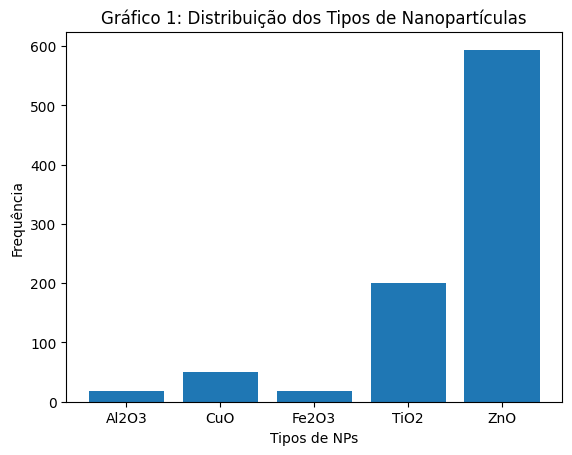

In [9]:
distribuicao = [df.loc[df["NPs_Al2O3"] == 1].shape[0],
                df.loc[df["NPs_CuO"] == 1].shape[0],
                df.loc[df["NPs_Fe2O3"] == 1].shape[0],
                df.loc[df["NPs_TiO2"] == 1].shape[0],
                df.loc[df["NPs_ZnO"] == 1].shape[0]]

plt.bar(range(len(distribuicao)), distribuicao)
plt.xlabel("Tipos de NPs")
plt.ylabel("Frequência")
plt.title("Gráfico 1: Distribuição dos Tipos de Nanopartículas")
plt.xticks(range(len(distribuicao)), ["Al2O3", "CuO", "Fe2O3", "TiO2", "ZnO"])
plt.show()

Além disso, as nanopartículas de Al2O3 e Fe2O3 são todas não tóxicas, como pode-se ver com o método `describe()`. Todavia, na atualização dos ATRIBUTOS após a técnica do *OneHotEncoder*, nanopartículas desses materiais não serão retiradas pois ainda constituem dados válidos. 

In [10]:
ATRIBUTOS = ["NPs_Al2O3", "NPs_CuO", "NPs_Fe2O3", "NPs_TiO2", "NPs_ZnO", "coresize", 
       "hydrosize", "surfcharge", "surfarea", "Ec", "e",
       "Expotime", "dosage"]


df = df.reindex(ATRIBUTOS + TARGET, axis=1)

## Gráficos 

Os gráficos abaixo mostram cada característica isoladamente para cada tipo de nanopartícula para rápida análise de possíveis correlações.

No gráfico 2, feito pela Inteligência Artificial (IA) Copilot com o módulo `matplotlib`, há os dados da "dosage" (dosagem) e "Expotime" (tempo de exposição), vistos como os atributos que mais influenciam na visualização de toxicidade de uma nanopartícula anteriormente. O gráfico consiste na visualização dos dados gerais das NPs com todas as relações possíveis entre os atributos.

Como no banco de dados não há especificado a medida de valor, assumo que a dosagem esteja em mililitros e o tempo de exposição em horas.

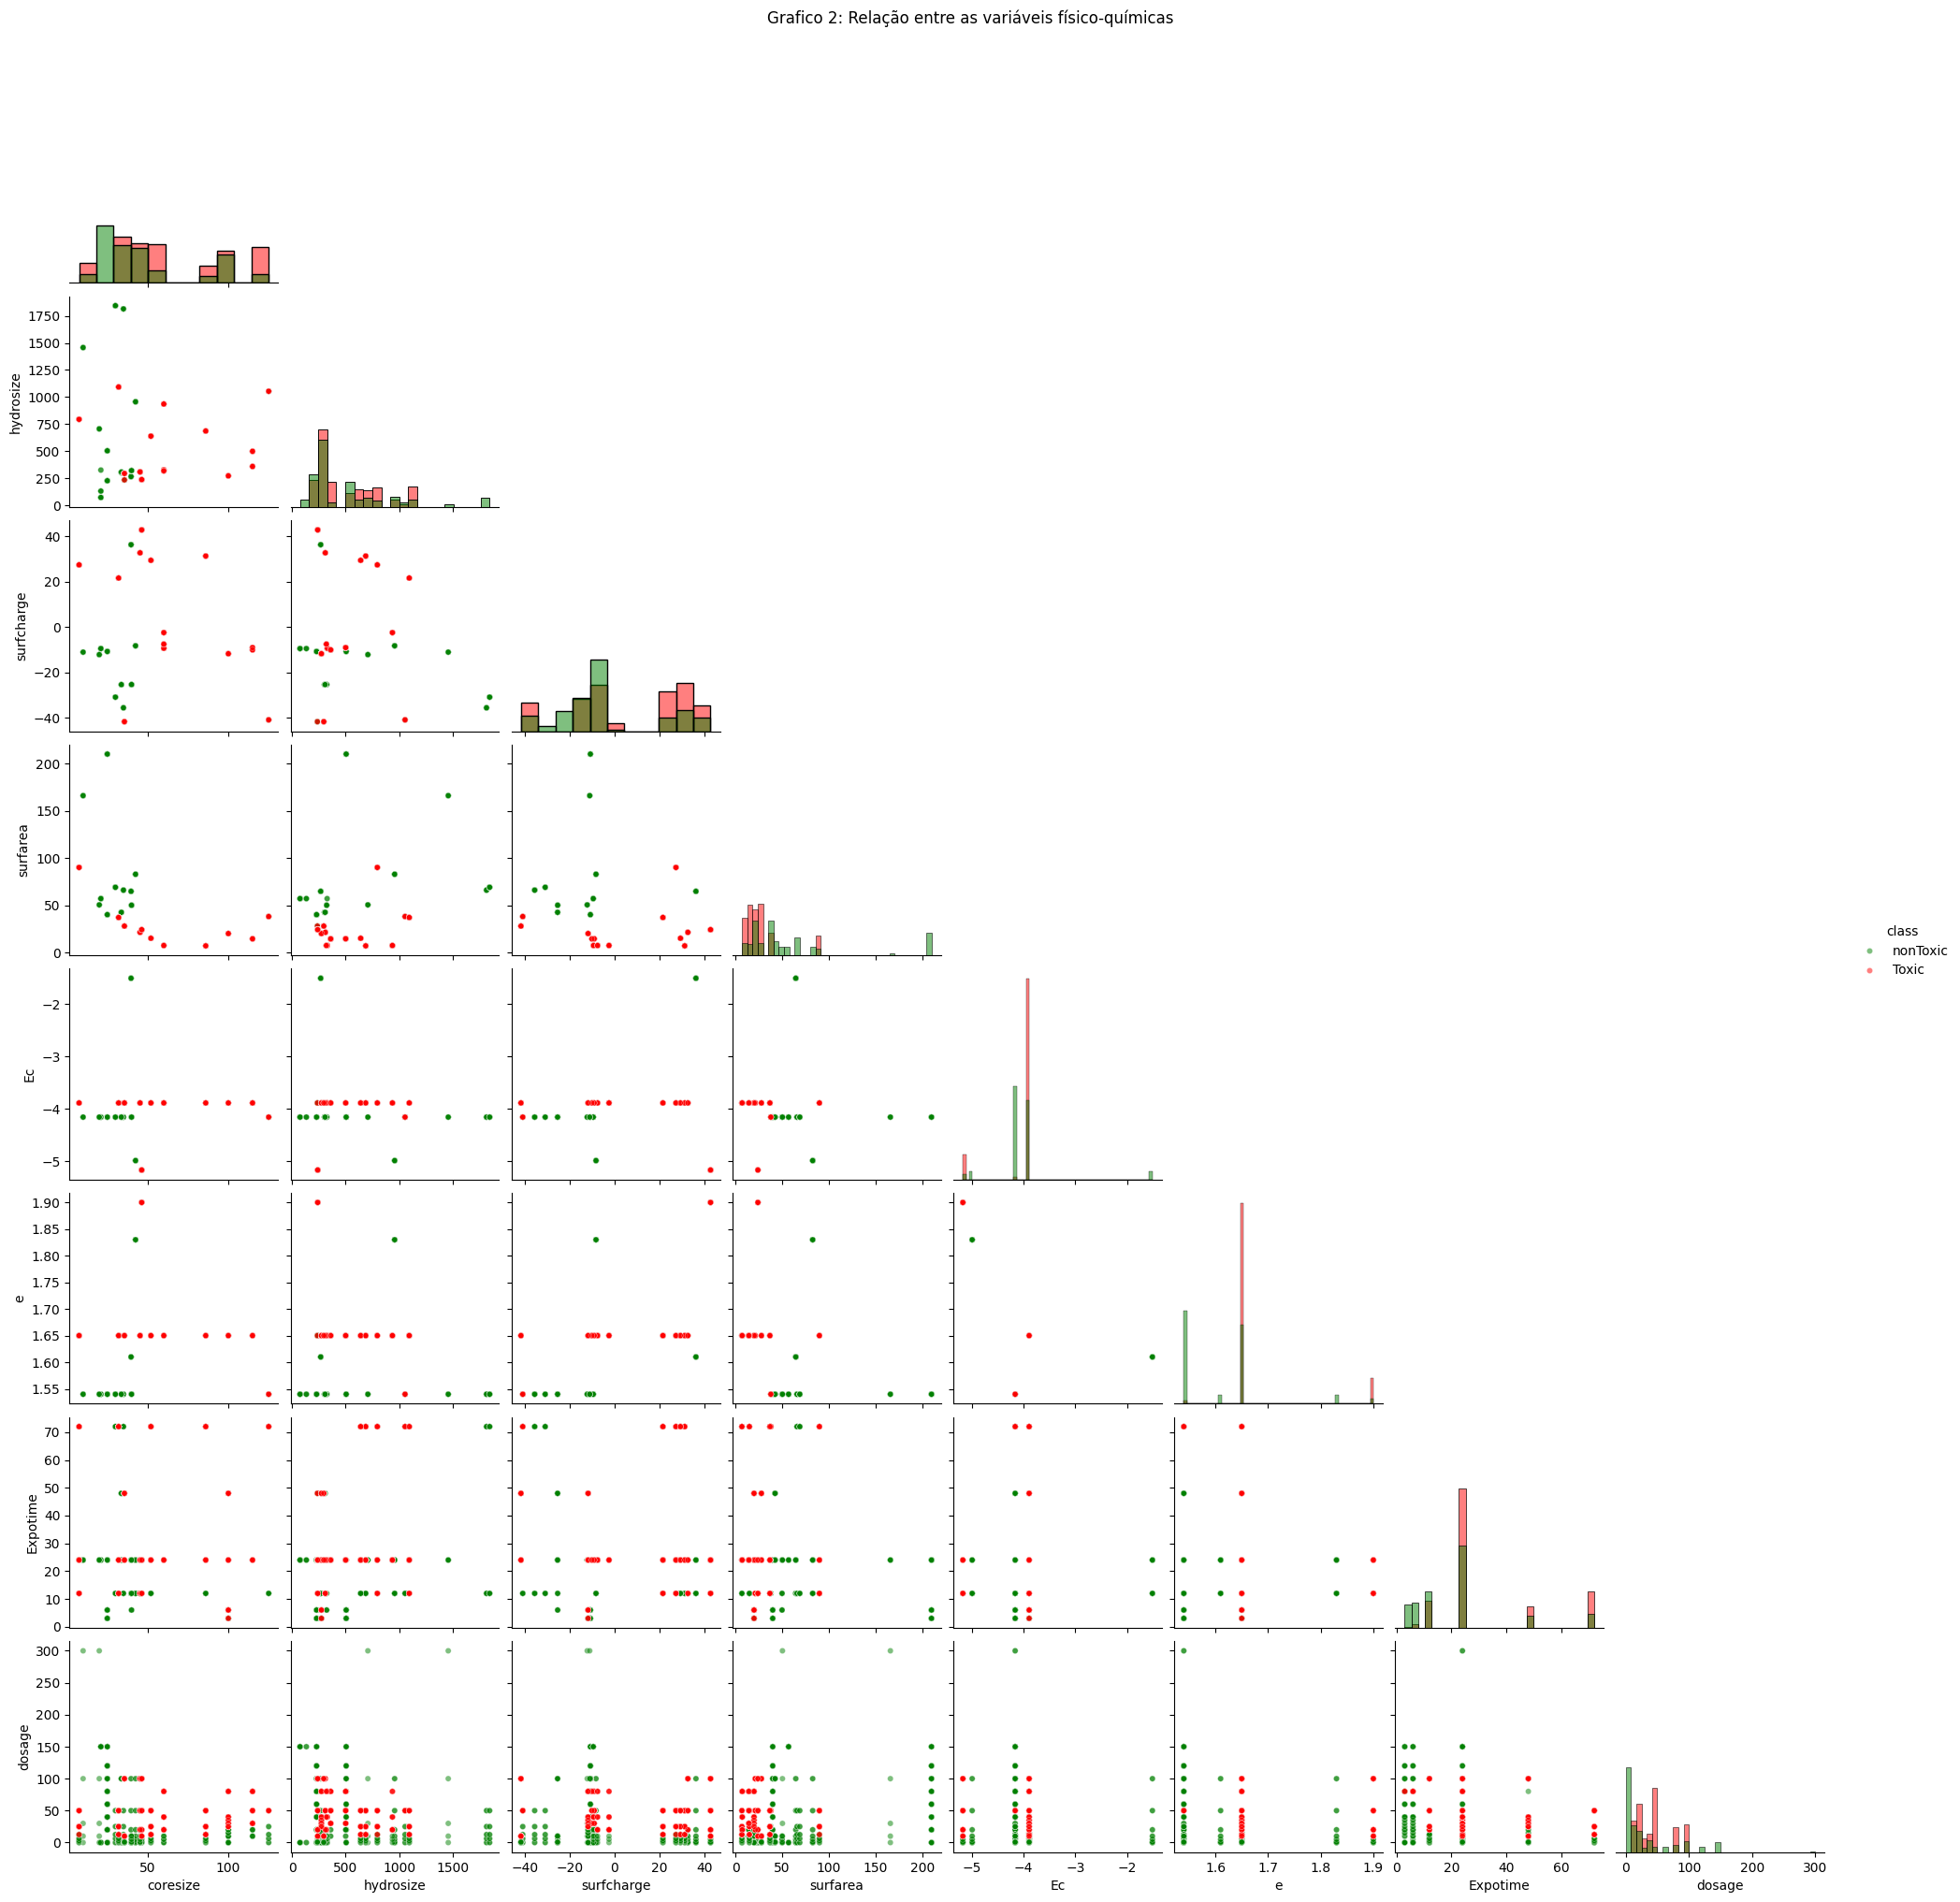

In [11]:
variaveis = [
    "coresize",
    "hydrosize",
    "surfcharge",
    "surfarea",
    "Ec",
    "e",
    "Expotime",
    "dosage"
]

g = sns.pairplot(
    df,
    vars=variaveis,
    hue="class",
    palette={
        "nonToxic": "green",
        "Toxic": "red"
    },
    corner=True,      # mostra apenas metade da matriz
    diag_kind="hist", # histogramas na diagonal
    plot_kws={
        "alpha": 0.5,
        "s": 20
    }
)

g.figure.suptitle(
    "Grafico 2: Relação entre as variáveis físico-químicas",
    y=1.02
)

plt.show()

Os gráficos do gráfico 2, relacionando todas as combinações possíveis de atributos (exceto pelo tipo de nanopartícula) e com diferença de cor entre as partículas tóxicas (vermelhas) e não tóxicas (verdes), demonstra que, em suma, há áreas com maior densidade de tóxicas e áreas com maior densidade de não tóxicas, isto é, os dados estão relativamente separados. Este fator de separação aumenta o desempenho do modelo de k-vizinhos próximos sem refletir necessariamente o aprendizado, ou seja, o superestima pois, com a inserção de dados desconhecidos, o modelo não estará bem treinado, podendo aumentar o índice de erro. Todavia, visto que os dados disponibilizados seguem essa regra, é possível que haja separação real nas características de NPs tóxicas e não tóxicas, não sendo, então, a separação um fator tão negativo.

## Treinando o modelo

Importando a biblioteca *scikit-learn* com o método `train_test_split` a fim de realizar o treinamento do modelo para o algorítmo de *k*-vizinhos próximos. A `SEMENTE_ALEATORIA` foi decidida arbitrariamente pelo autor a fim de criar reprodutibilidade nos dados.

O tamanho do teste foi escolhido com 15% pois o banco de dados tem bastante exemplos, o que gera uma boa parcela de teste e um grande número de dados restantes para treinar o algorítmo. O código foi feito com auxílio de Cassar (2026) [2].

O método `.values.ravel()` é utilizado para

In [12]:
TAMANHO_TESTE = 0.15
SEMENTE_ALEATORIA = 73701

indices = df.index

indices_treino, indices_teste = train_test_split(
    indices, test_size=TAMANHO_TESTE, random_state=SEMENTE_ALEATORIA, stratify=df[TARGET]
)

df_treino = df.loc[indices_treino]
df_teste = df.loc[indices_teste]

x_treino = df_treino[ATRIBUTOS]
y_treino = df_treino[TARGET].values.ravel()

x_teste = df_teste[ATRIBUTOS]
y_teste = df_teste[TARGET].values.ravel()

Como os dados estão em escalas diferentes (alta diferença entre tamanho hidrodinâmico e energy-related feature, por exemplo), serão realizadas três formas de normalização dos dados: normalização padrão com o método `StandardScaler`, normalização pelo máximo absoluto `MaxAbsScaler` e normalização com o mínimo e máximo com o método `MinMaxScaler`. A forma utilizada para o primeiro uso do modelo será a padrão.

In [13]:
scaler_padrao = StandardScaler()
x_treino_padronizado = scaler_padrao.fit_transform(x_treino)
x_teste_padronizado = scaler_padrao.transform(x_teste)

scaler_maxabs = MaxAbsScaler()
x_treino_maxabs = scaler_maxabs.fit_transform(x_treino)
x_teste_maxabs = scaler_maxabs.transform(x_teste)

scaler_minmax = MinMaxScaler()
x_treino_minmax = scaler_minmax.fit_transform(x_treino)
x_teste_minmax = scaler_minmax.transform(x_teste)

A fim de classificar de forma binária deve haver uma ordem específica.

In [14]:
ordem_labels = df["class"].unique().tolist()

ordem_labels

['nonToxic', 'Toxic']

## Modelo Baseline

O método `DummyClassifier` criará um modelo de *baseline* para utilizar como referência para comparar com a eficiência do modelo complexo criado mais adiante. O método `fit` tem função de armazenar na memória o modelo treinado. Abaixo o modelo é treinado. Para a primeira análise dos modelos, a normalização utilizada será a padrão.

In [15]:
modelo_baseline = DummyClassifier()
modelo_baseline.fit(x_treino_padronizado, y_treino)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'prior'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.54,0.46]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[object](2,)","['Toxic','nonToxic']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,13
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


Importando o método `confusion_matrix` para criar uma visualização gráfica da matriz de confusão. Essa matriz retorna os tipos de acertos e tipos de erros na previsão. Os possíveis acertos são: verdadeiro positivo (VP), quando a NP real é não tóxica e a predita é, também, não tóxica, e verdadeiro negativo (VN), quando a NP real é tóxica e a predita é, também, tóxica. Os possíveis erros são: falso positivo (FP), quando a NP real é tóxica e é predita como não tóxica, e falso negativo (FN), quando a NP real é não tóxica e é predita como tóxica. 

Vale pontuar que todo erro deve ser evitado, mas, nesse caso de predição de toxicidade, o FP é mais perigoso. Isso ocorre pois o FP fornece confiança ao manejar com menos cuidado que o necessário de NPs que são, na realidade, tóxicas. Enquanto isso, o FN apenas provê maior cuidado possivelmente desnecessário.

In [16]:
y_verdadeiro = y_teste
y_previsao = modelo_baseline.predict(x_teste_padronizado)

matriz_conf = confusion_matrix(y_verdadeiro, y_previsao, labels=ordem_labels)
df_conf_baseline = pd.DataFrame(matriz_conf, ordem_labels, ordem_labels)

O resultado de acurácia do modelo Baseline pode ser visualizada no gráfico 3.

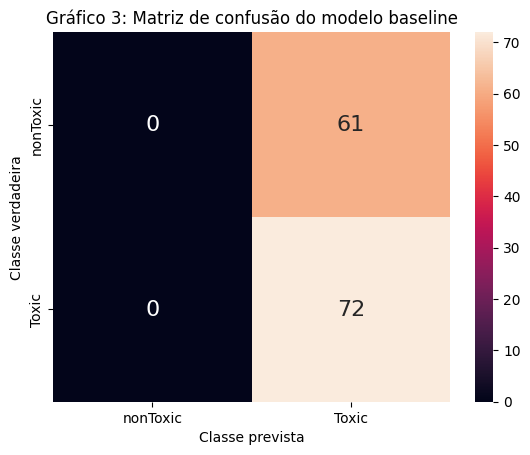

In [17]:
sns.heatmap(df_conf_baseline, annot=True, annot_kws={"size": 16})

plt.title("Gráfico 3: Matriz de confusão do modelo baseline")
plt.xlabel("Classe prevista")
plt.ylabel("Classe verdadeira")
plt.show()

Dada a matriz de confusão com as bibliotecas *scikit-learn* e *seaborn*, a fim de medir o desempenho do modelo apenas com base nas previsões certas e erradas, será utilizada a acurácia (1). A acurácia é uma boa métrica de desempenho nesse caso porque os dados (na categorização binária) estão relativamente balanceados e é direta pois mostra a porcentagem de acerto do modelo.

\begin{equation}
\mathrm{ACC = \frac{VP + VN}{VP + FP + VN + FN}}
\end{equation}

A acurácia do modelo Baseline pode ser vista abaixo:

In [18]:
acuracia_baseline = accuracy_score(y_verdadeiro, y_previsao)

print(f"Acurácia do modelo Baseline = {(acuracia_baseline*100):.2f}%")

Acurácia do modelo Baseline = 54.14%


Ao criar o modelo Baseline, este utiliza, com dados categóricos de classificação binária, a moda de todos os dados a fim de fazer a previsão, ou seja, é um modelo que não leva em conta os atributos para realizar a previsão. A acurácia do Baseline de apenas 54.14% demonstra que os dados estão balanceados no *target* e nos incentiva, por ser um baixo valor, a procurar melhores modelos para classificação.

O modelo utilizado, no caso, será o *k*-vizinhos próximos.

## Implementação do *k*-NN

O *k*-NN importado da biblioteca *scikit* será o `KNeighborsClassifier`, pois o problema a ser resolvido neste caderno é de classificação binária. Abaixo o modelo é treinado com o hiperparâmetro de número de vizinhos igual a 3 por ser um número ímpar, evitando empates, e é um valor pequeno, equilibrando viés e variância. Além disso, a distância calculada será a euclidiana e todos os vizinhos terão o mesmo peso. Mais adiante serão realizadas variações nesses hiperparâmetros a fim de deduzir o melhor conjunto de hiperparâmetros. O modelo é treinado abaixo.

In [19]:
NUM_VIZINHOS = 3

modelo_knn = KNeighborsClassifier(NUM_VIZINHOS)
modelo_knn.fit(x_treino_padronizado, y_treino)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](2,)","['Toxic','nonToxic']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


Abaixo a variável `y_previsao` receberá os valores previstos pelo modelo, após treinado, ao classificar os dados da variável `x_teste_padronizado`.

In [20]:
y_verdadeiro = y_teste
y_previsao = modelo_knn.predict(x_teste_padronizado)

matriz_conf = confusion_matrix(y_verdadeiro, y_previsao, labels=ordem_labels)
df_conf_knn = pd.DataFrame(matriz_conf, ordem_labels, ordem_labels)

A matriz de confusão com o modelo *k*-NN pode ser vista no gráfico 4.

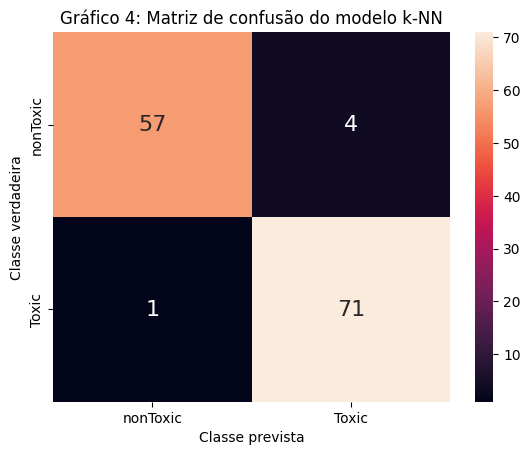

In [21]:
sns.heatmap(df_conf_knn, annot=True, annot_kws={"size": 16})

plt.title("Gráfico 4: Matriz de confusão do modelo k-NN")
plt.xlabel("Classe prevista")
plt.ylabel("Classe verdadeira")
plt.show()

Calculando a acurácia desse modelo.


In [22]:
acuracia_knn = accuracy_score(y_verdadeiro, y_previsao)

print(f"Acurácia do modelo k-NN = {(acuracia_knn*100):.2f}%")

Acurácia do modelo k-NN = 96.24%


Com o modelo *k*-NN houve um aumento exorbitante na acurácia quando comparado ao Baseline, de aproximadamente 42%. Uma possível razão para essa alta acurácia é que os dados sejam bem separados que, em conjunto com o baixo número de vizinhos, performou muito bem. Mais adiante, com a variação dos hiperparâmetros, a questão da boa separação entre as classes será discutida. É interessante notar que houve apenas um falso positivo, dentre as cinco classificações errôneas. Isso nos dá um bom indicativo de que, mesmo havendo erros, é menos provável que seja cometido o erro mais grave. 

## Variação de hiperparâmetros

Escolher o melhor conjunto de hiperparâmetros é um problema NP-difícil, sendo necessário testar vários conjuntos e visualizar seus resultados. Assim, serão feitas algumas variações na variável de vizinhos `k`, na forma como o cálculo da distância é feito (euclidiana, manhattan e minkowski) e no peso da distância (sem peso, com peso). No código abaixo são calculadas as acurácias de cada valor *k*, com 10 variações, variando, também, os três tipos de normalizações serão analisados a fim de compreender qual seria a mais adequada neste contexto. O tipo de distância utilizado é constante e com peso.

In [23]:
NUM_VIZINHOS = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]  # 10 valores de k
TIPO_PESO = "distance"

acuracias_og = []
acuracias_max = []
acuracias_min = []

# Rodar o modelo com normalização padrão
for n_vizinhos in NUM_VIZINHOS:
    
    modelo_padrao = KNeighborsClassifier(n_neighbors=n_vizinhos, weights=TIPO_PESO)

    modelo_padrao.fit(x_treino_padronizado, y_treino)

    y_verdadeiro = y_teste
    y_previsao = modelo_padrao.predict(x_teste_padronizado)

    acc_padrao = accuracy_score(y_verdadeiro, y_previsao)

    acuracias_og.append(acc_padrao)

# Rodar o modelo com normalização MaxAbs
for n_vizinhos in NUM_VIZINHOS:
    
    modelo_maxabs = KNeighborsClassifier(n_neighbors=n_vizinhos, weights=TIPO_PESO)

    modelo_maxabs.fit(x_treino_maxabs, y_treino)

    y_verdadeiro = y_teste
    y_previsao = modelo_maxabs.predict(x_teste_maxabs)

    acc_max = accuracy_score(y_verdadeiro, y_previsao)

    acuracias_max.append(acc_max)

# Rodar o modelo com normalização MinMax
for n_vizinhos in NUM_VIZINHOS:
    
    modelo_minmax = KNeighborsClassifier(n_neighbors=n_vizinhos, weights=TIPO_PESO)

    modelo_minmax.fit(x_treino_minmax, y_treino)

    y_verdadeiro = y_teste
    y_previsao = modelo_minmax.predict(x_teste_minmax)

    acc_min = accuracy_score(y_verdadeiro, y_previsao)

    acuracias_min.append(acc_min)

O gráfico com as acurácias de cada número *k* de vizinho e cada normalização foi feito com a biblioteca `matplotlib` e auxílio da IA.

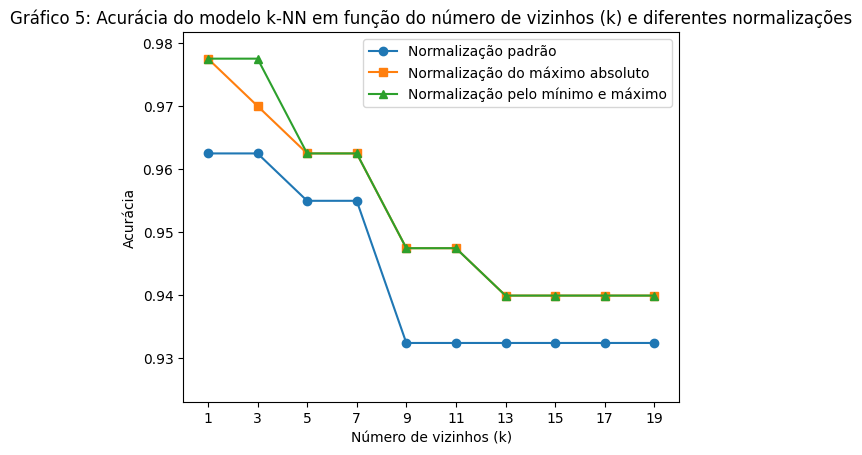

In [24]:
plt.plot(NUM_VIZINHOS, acuracias_og, marker="o", label="Normalização padrão")
plt.plot(NUM_VIZINHOS, acuracias_max, marker="s", label="Normalização do máximo absoluto")
plt.plot(NUM_VIZINHOS, acuracias_min, marker="^", label="Normalização pelo mínimo e máximo")

plt.xticks(NUM_VIZINHOS)  # mostra apenas os valores da lista

plt.xlim(min(NUM_VIZINHOS)-1, max(NUM_VIZINHOS)+1)
plt.ylim(0.99*min(acuracias_og), 1.02*max(acuracias_og))

plt.title("Gráfico 5: Acurácia do modelo k-NN em função do número de vizinhos (k) e diferentes normalizações")
plt.xlabel("Número de vizinhos (k)")
plt.ylabel("Acurácia")
plt.legend()

plt.show()

No gráfico 5, a melhor acurácia, com um altíssimo valor, é encontrada com o menor número de vizinhos, indicando que os dados estão com separação na classe. Além da separação dos dados explicar o número baixo de vizinhos, a normalização do mínimo e máximo performou ainda melhor que a normalização padrão e melhor em um ponto em relação à normalização do máximo absoluto. A normalização padrão provavelmente obteve um desempenho inferior pois não força um intervalo específico, o que deve ter permitido ainda valores bem diferentes por conta da diferença entre as escalas. Já as normalizações de máximo absoluto e de mínimo e máximo forçam um intervalo mais homogênio nos dados, o que beneficia o modelo que prevê de acordo com a distância utilizado.

A fim de escolher o melhor conjunto de hiperparâmetros, como o problema é NP-difícil, temos que testar vários conjuntos e visualizar seus resultados. Assim, serão feitas variações na variável de vizinhos `k` com valores de [1, 3, 5, 7], na forma como o cálculo da distância é feito (euclidiana, manhattan e minkowski) e no peso da distância (sem peso, com peso) [3]. Serão utilizados os dados com normalização de mínimo e máximo, pois obteve a melhor performance.

In [25]:
NUM_VIZINHOS = [1, 3, 5, 7] 
NUM_DISTANCIA = [1, 2, 3]  # 1 Manhattan, 2 Euclidiana, 3 Minkowski
TIPO_PESO = ["uniform", "distance"]

acc_max = 0

for n_vizinhos, p_distancia, peso in product(
    NUM_VIZINHOS, NUM_DISTANCIA, TIPO_PESO
):
    modelo = KNeighborsClassifier(n_neighbors=n_vizinhos, p=p_distancia, weights=peso)

    modelo.fit(x_treino_minmax, y_treino)

    y_verdadeiro = y_teste
    y_previsao = modelo.predict(x_teste_minmax)

    acc = accuracy_score(y_verdadeiro, y_previsao)

    if acc>acc_max:
        k_max = n_vizinhos
        p_max = p_distancia
        weights_max = peso
        acc_max = acc

    print(
        f"n_neighbors={n_vizinhos},   "
        f"p={p_distancia},   "
        f"weights='{peso}'   "
        f"Acurácia: {100*acc:.4}%."
    )


print(f"\nA melhor acurácia foi com n_neighbors={k_max}  p={p_max}   weights={weights_max}  acurácia={100*acc_max:.2f}%")

n_neighbors=1,   p=1,   weights='uniform'   Acurácia: 97.74%.
n_neighbors=1,   p=1,   weights='distance'   Acurácia: 97.74%.
n_neighbors=1,   p=2,   weights='uniform'   Acurácia: 97.74%.
n_neighbors=1,   p=2,   weights='distance'   Acurácia: 97.74%.
n_neighbors=1,   p=3,   weights='uniform'   Acurácia: 97.74%.
n_neighbors=1,   p=3,   weights='distance'   Acurácia: 97.74%.
n_neighbors=3,   p=1,   weights='uniform'   Acurácia: 97.74%.
n_neighbors=3,   p=1,   weights='distance'   Acurácia: 97.74%.
n_neighbors=3,   p=2,   weights='uniform'   Acurácia: 97.74%.
n_neighbors=3,   p=2,   weights='distance'   Acurácia: 97.74%.
n_neighbors=3,   p=3,   weights='uniform'   Acurácia: 97.74%.
n_neighbors=3,   p=3,   weights='distance'   Acurácia: 97.74%.
n_neighbors=5,   p=1,   weights='uniform'   Acurácia: 90.23%.
n_neighbors=5,   p=1,   weights='distance'   Acurácia: 96.24%.
n_neighbors=5,   p=2,   weights='uniform'   Acurácia: 90.23%.
n_neighbors=5,   p=2,   weights='distance'   Acurácia: 96.24%.


A melhor performance do modelo (97.74%) foi com número de vizinhos k = 1, mas o mesmo valor de acurácia se repetiu com diversas combinações de hiperparâmetros, com k = [1, 3]. O que mais uma vez corrobora com a ideia dos dados de mesma classe estarem bem próximos. A melhor combinação, todavia, deve ser com k=3, pois é menos sensível que k=1, causando menor variância. Além disso, os demais hiperparâmetros seriam com peso de acordo com a distância e a distância padrão Euclidiana, pois não foi visível nenhuma diferença entre as diferentes formas de calcular a distância (Manhattan, Euclidiana ou Minkowski). Por último, vejamos o gráfico 6 com a matriz confusão do modelo discutido nesta célula.

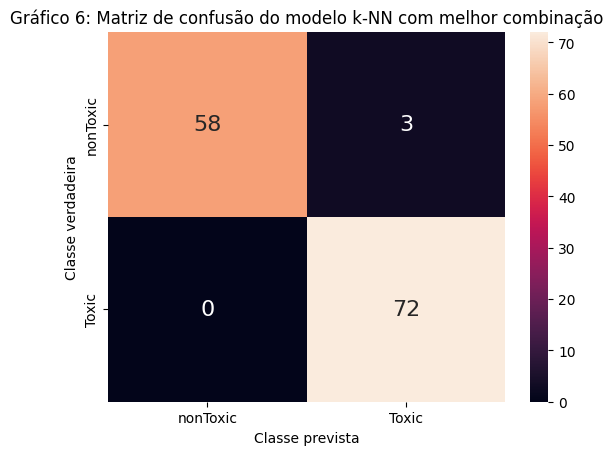

In [26]:
NUM_VIZINHOS = 3
TIPO_PESO = "distance"

modelo_knn = KNeighborsClassifier(NUM_VIZINHOS, weights=TIPO_PESO)
modelo_knn.fit(x_treino_minmax, y_treino)

y_verdadeiro = y_teste
y_previsao = modelo_knn.predict(x_teste_minmax)

matriz_conf = confusion_matrix(y_verdadeiro, y_previsao, labels=ordem_labels)
df_conf_knn = pd.DataFrame(matriz_conf, ordem_labels, ordem_labels)

sns.heatmap(df_conf_knn, annot=True, annot_kws={"size": 16})

plt.title("Gráfico 6: Matriz de confusão do modelo k-NN com melhor combinação")
plt.xlabel("Classe prevista")
plt.ylabel("Classe verdadeira")
plt.show()

Além de poucos erros cometidos, o modelo, com essa configuração não houveram erros falso positivos (quando a particula real é tóxica e é prevista como não tóxica), discutidos anteriormente como mais perigosos por fornecerem uma falsa segurança com a nanopartícula.

## Conclusões e principais aprendizados

O desenvolvimento deste caderno permitiu construir e avaliar um classificador k-NN para prever a toxicidade de nanopartículas, comparando-o com um modelo baseline e explorando os efeitos que diferentes hiperparâmetros possuem (número de vizinhos, métrica de distância, esquema de peso e tipo de normalização).

O modelo k-NN superou consideravelmente o baseline (54,14% de acurácia), atingindo até 97,74% de acurácia nas melhores combinações. A busca em grade mostrou que valores baixos de k (1 ou 3) obtiveram o melhor desempenho, independente da métrica de distância utilizada (Manhattan, Euclidiana ou Minkowski) ou do esquema de peso. Mesmo k=1 e k=3 com o mesmo desempenho, k=3 é um melhor valor para um modelo final, visto que é menos sensível a ruído em pontos individuais do que k=1, que tende a ter maior variância mesmo quando performa bem em um teste específico. Além disso, é visível que o modelo obteve melhor desempenho com peso na distância e os dados normalizados com a normalização de mínimo e máximo.

Olhando a matriz de confusão do modelo final (gráfico 6), houveram 0 falso positivo (NP realmente tóxica prevista como não tóxica) e 3 falsos negativos (NP realmente não tóxica prevista como tóxica), totalizando 3 erros em 133 exemplos de teste. Do ponto de vista de aplicação prática, o falso positivo é o erro mais preocupante, pois gera uma falsa sensação de segurança em relação a uma nanopartícula que de fato é tóxica, sendo esse um aspecto positivo do modelo.

Por fim, este caderno é válido não tanto pela acurácia de 97,74%, mas no processo de desenvolvimento do algorítmo de aprendizado de máquina, com análise exploratória prévia ao banco de dados, comparação com baseline e exploração de hiperparâmetros e normalizações. 

## Referências

[1] https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html

[2] CASSAR, Daniel Roberto. Aprendizado de Máquina, Bacharel em Ciência e Tecnologia, Ilum, Campinas. 2026. 

[3] https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

## Descrição do uso da IA neste trabalho

A Inteligência artificial foi utilizada para auxiliar com a construção de gráficos, especialmente com o módulo matplotlib e seaborn. Além disso, foi utilizada também para correção e melhora do texto, ainda preservando a autoria do texto.